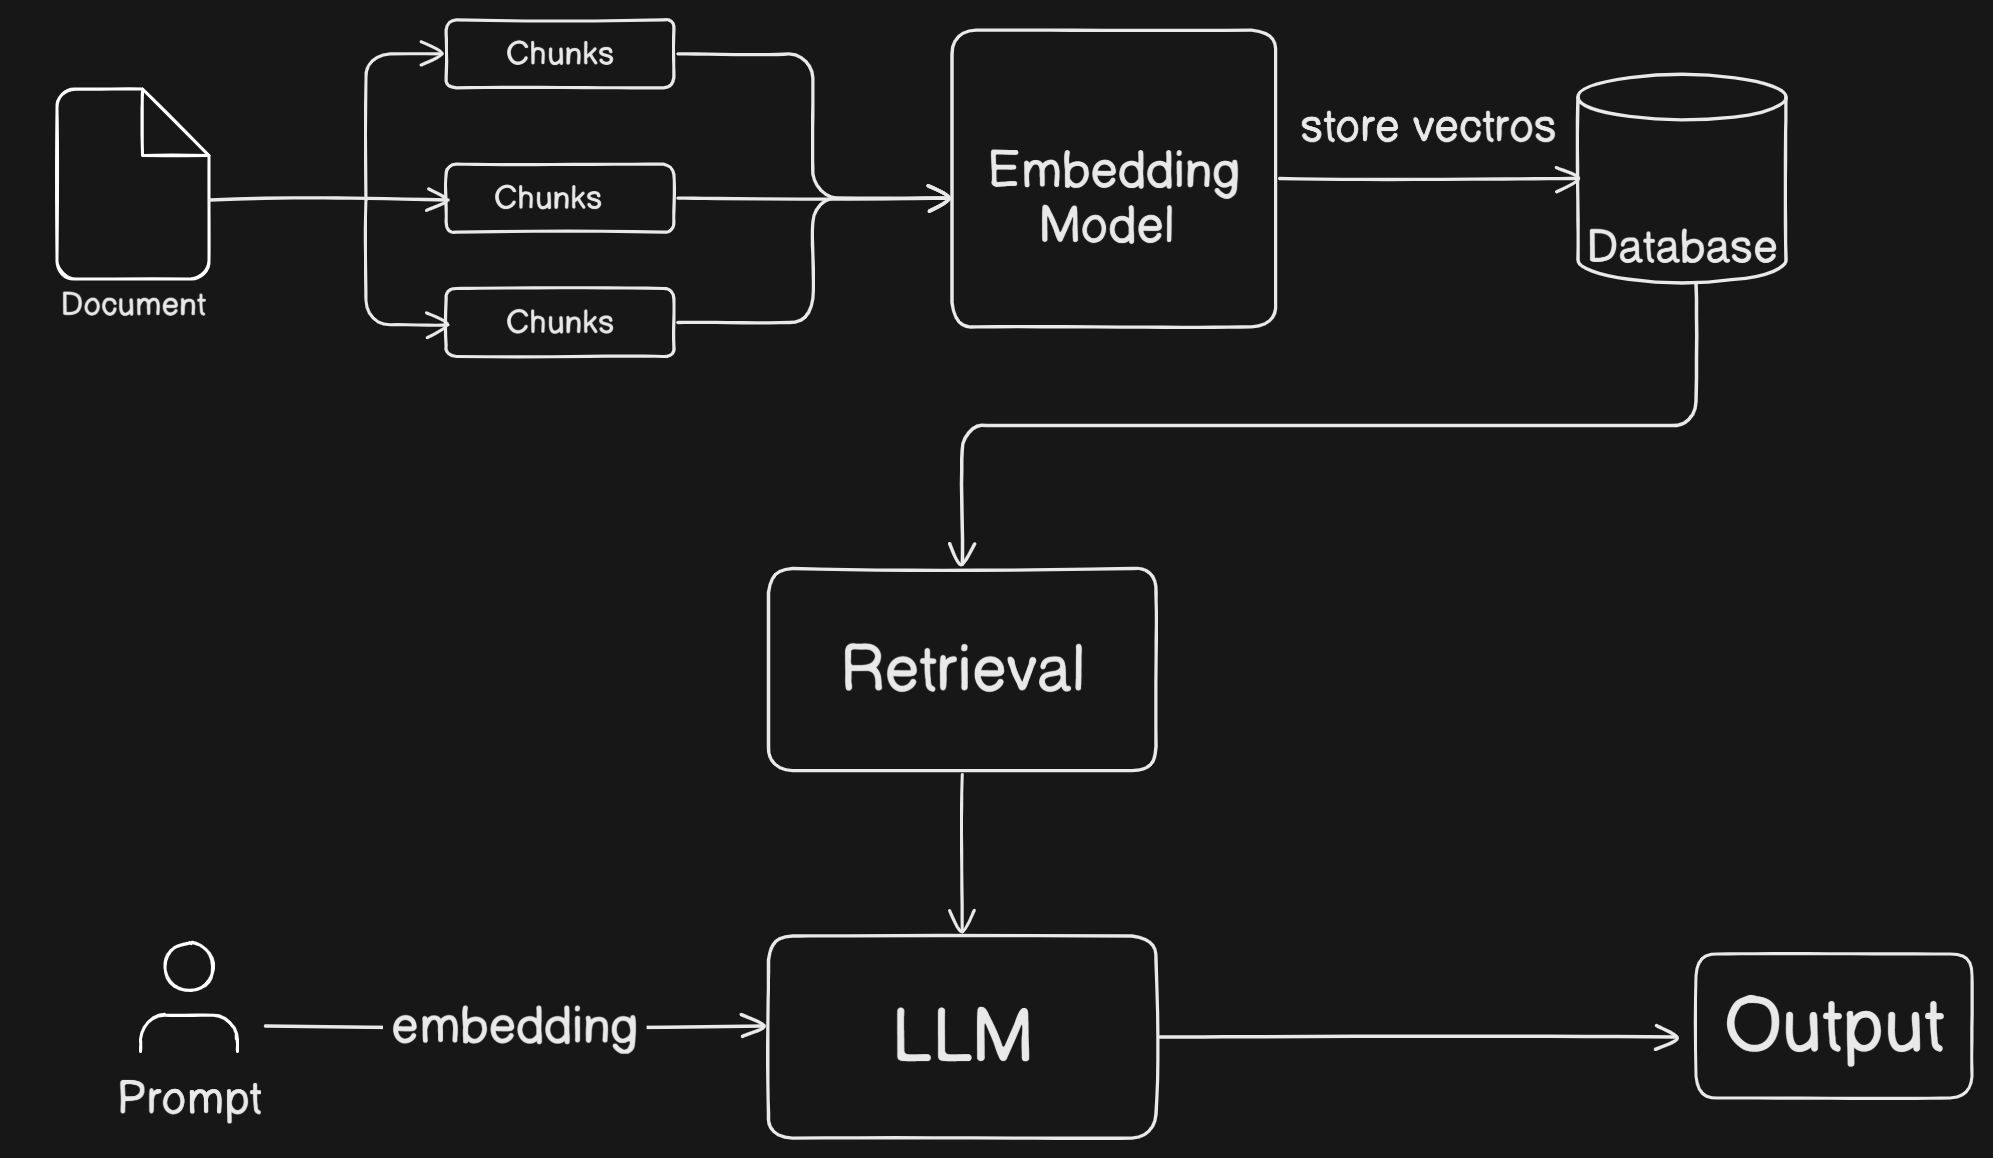

In [3]:
%pip list

Package                   Version
------------------------- -----------
anyio                     4.13.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.7
colorama                  0.4.6
comm                      0.2.3
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
exceptiongroup            1.3.1
executing                 2.2.1
fastjsonschema            2.21.2
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.17
ipykernel                 7.2.0
ipython                   8.39.0
ipywidgets        

In [ ]:
%pip install langchain_openai

     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 320.0 kB/s eta 0:00:01
     ---------------------------- --------- 30.7/41.5 kB 325.1 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 221.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----------------- ---------------------- 30.7/70.6 kB 1.3 MB/s eta 0:00:01
   ----------------------- ---------------- 41.0/70.6 kB 960.0 kB/s eta 0:00:01
   ----------------------- ---------------- 41.0/70.6 kB 960.0 kB/s eta 0:00:01
   ---------------------------------------- 70.6/70.6 kB 384.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/893.9 kB ? eta -:--:--
   -- ------------------------------------- 61.4/893.9 kB 1.7 MB/s eta 0:00:01
   ----- ---------------------------------- 122.9/893.9 kB 1.4 MB/s eta 0:00:

In [ ]:
%pip install langchain_qdrant

   ---------------------------------------- 0.0/337.3 kB ? eta -:--:--
   - -------------------------------------- 10.2/337.3 kB ? eta -:--:--
   --- ----------------------------------- 30.7/337.3 kB 660.6 kB/s eta 0:00:01
   ---- ---------------------------------- 41.0/337.3 kB 495.5 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/337.3 kB 365.7 kB/s eta 0:00:01
   ---------- ---------------------------- 92.2/337.3 kB 438.1 kB/s eta 0:00:01
   ------------ ------------------------- 112.6/337.3 kB 437.6 kB/s eta 0:00:01
   ------------- ------------------------ 122.9/337.3 kB 400.9 kB/s eta 0:00:01
   --------------------- ---------------- 194.6/337.3 kB 562.0 kB/s eta 0:00:01
   ------------------------- ------------ 225.3/337.3 kB 626.9 kB/s eta 0:00:01
   --------------------------- ---------- 245.8/337.3 kB 559.4 kB/s eta 0:00:01
   -------------------------------- ----- 286.7/337.3 kB 590.8 kB/s eta 0:00:01
   ------------------------------------ - 327.7/337.3 kB 

In [6]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore

In [9]:
pdf_path = (
    Path("C:\D\Working\Machine Learning\ML Books\ML Books\AI Engineering.pdf").parent
    / "AI Engineering.pdf"
)

In [ ]:
%pip install pypdf

   ---------------------------------------- 0.0/313.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/313.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/313.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/313.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/313.2 kB 259.2 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/313.2 kB 217.9 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/313.2 kB 272.3 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/313.2 kB 327.7 kB/s eta 0:00:01
   ----------- --------------------------- 92.2/313.2 kB 327.7 kB/s eta 0:00:01
   ----------------- -------------------- 143.4/313.2 kB 387.0 kB/s eta 0:00:01
   ------------------- ------------------ 163.8/313.2 kB 426.7 kB/s eta 0:00:01
   --------------------- ---------------- 174.1/313.2 kB 388.2 kB/s eta 0:00:01
   ----------------------------- -------- 245.8/313.2 kB 502.2 kB/s eta 0:

In [ ]:
loader = PyPDFLoader(file_path=pdf_path)
docs = loader.load()

In [13]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

In [14]:
split_docs = text_splitter.split_documents(documents=docs)

In [ ]:
embedder = OpenAIEmbeddings(
    model="text-embedding-3-large",
    api_key="OPENAI_API_KEY",
)

In [ ]:
vector_store = QdrantVectorStore.from_documents(
    documents=[],
    url="https://localhost:6333",
    collection_name="collection_name",
    embedding=embedder,
)

In [ ]:
vector_store.add_documents(documents=split_docs)
print("Injection Done")

In [ ]:
retriever = QdrantVectorStore.from_existing_collection(
    url="https://localhost:6333", collection_name="collection_name", embedding=embedder
)

In [ ]:
relevant_chunks = retriever.similarity_search(
    query="user_query",
)

In [ ]:
SYSTEM_PROMPT = f"""You are a helpful assistant that responds based on the given context.Context:{relevant_chunks}
"""